In [10]:
# Importing Libraries
import pandas as pd                              # Pandas: work with and analyze tabular data
from datasets import load_dataset               # Hugging Face: load the job postings dataset
import matplotlib.pyplot as plt                 # Matplotlib: create charts and visualizations


# Loading Data
dataset = load_dataset('lukebarousse/data_jobs') # Download/load Luke's job dataset
df = dataset['train'].to_pandas()                # Convert the dataset into a Pandas DataFrame


# Data Cleanup
df['job_posted_date'] = pd.to_datetime(
    df['job_posted_date']                      # Convert the date column values to datetime objects
)

In [11]:
# Create a pivot table grouped by job title and count each group

df.pivot_table(
    index='job_title_short',  # Group rows by the job title column
    aggfunc='size'            # Count how many rows are in each group
)

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

## Median Salary by job


In [12]:
# Create a pivot table showing the median salary by job title

df.pivot_table(
    values='salary_year_avg',  # Use the salary column as the value to summarize
    index='job_title_short',   # Group rows by the job title column
    aggfunc='median'           # Calculate the median salary for each group
)

,salary_year_avg
job_title_short,
Business Analyst,85000.0
Cloud Engineer,90000.0
Data Analyst,90000.0
Data Engineer,125000.0
Data Scientist,127500.0
Machine Learning Engineer,106415.0
Senior Data Analyst,111175.0
Senior Data Engineer,147500.0
Senior Data Scientist,155500.0


In [13]:
# Group rows by job title and calculate the median salary for each group

df.groupby('job_title_short')['salary_year_avg'].median()  # Group by job title, select the salary column, and calculate the median

job_title_short
Business Analyst              85000.0
Cloud Engineer                90000.0
Data Analyst                  90000.0
Data Engineer                125000.0
Data Scientist               127500.0
Machine Learning Engineer    106415.0
Senior Data Analyst          111175.0
Senior Data Engineer         147500.0
Senior Data Scientist        155500.0
Software Engineer             99150.0
Name: salary_year_avg, dtype: float64

<Axes: xlabel='job_title_short'>

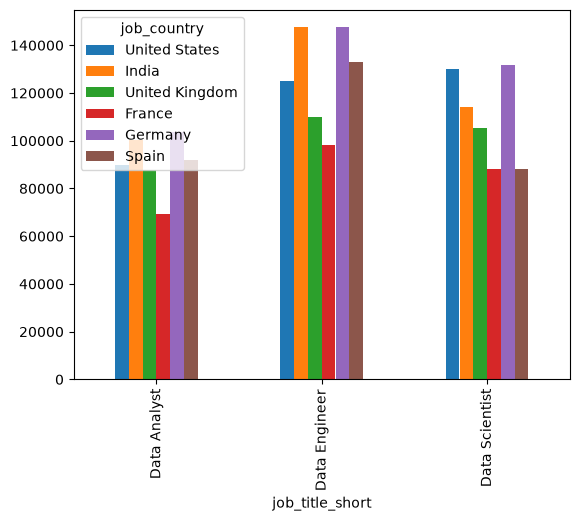

In [26]:
# Get the 6 countries with the most job postings
top_countries = df['job_country'].value_counts().head(6).index  # Count postings → top 6 → return country names


# Create a pivot table comparing median salaries across job titles and countries
df_job_country_salary = df.pivot_table(
    values='salary_year_avg',   # VALUES = numbers we want to analyze (annual salary)
    index='job_title_short',    # INDEX = rows → each row represents a job title
    columns='job_country',      # COLUMNS = columns → each column represents a country
    aggfunc='median'            # AGGFUNC = summarize salaries by calculating the median
)


# Keep only the 6 countries with the most job postings
df_job_country_salary = df_job_country_salary.loc[:, top_countries]  # : = all rows, top_countries = selected columns


# Create a list of the specific job titles we want to compare
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']  # Python list containing our 3 target job titles


# View only the selected job-title rows
df_job_country_salary.loc[job_titles]  # .loc selects rows by their labels (job titles)


# Plot the selected job titles and their median salaries across countries
df_job_country_salary.loc[job_titles].plot(kind='bar')  # Convert the selected data into a bar chart